# Fraud detection


## Mục Tiêu
- Đọc và kiểm tra dữ liệu gốc, phát hiện vấn đề tiềm ẩn
- Thực hiện Phân Tích Dữ Liệu Khám Phá (EDA) theo logic học thuật, từ tổng quan đến chi tiết
- Xây dựng feature engineering cho giao dịch, thời gian và vị trí địa lý (sử dụng công thức Haversine)
- Xây dựng baseline và các mô hình dựa trên cây (tree-based models)
- Đánh giá bằng precision, recall, F1, ROC-AUC, PR-AUC
- Chọn threshold hợp lý cho bài toán fraud detection (threshold tuning)

## Cấu Trúc Notebook

### 1. SETUP & IMPORT
- Setup và import thư viện

### 2. TIỀN XỬ LÝ DỮ LIỆU
- **2.1 Trích xuất dữ liệu**: Nạp dữ liệu từ file CSV
- **2.2 Kiểm tra nhanh dataset**: Tổng quan hình dạng, tỷ lệ fraud, missing values
- **2.3 EDA cơ bản**: Phân tích dữ liệu gốc (kiểu dữ liệu, giá trị thiếu, fraud rate by category/state/gender)
- **2.4 Làm sạch dữ liệu**: Xử lý missing, duplicates, loại bỏ cột hằng
- **2.5 Lựa chọn & Kỹ thuật đặc trưng**: Tạo features (hour, age, distance_km, amt_log) + EDA mở rộng
- **2.6 Tiền xử lý chính thức**: Pipeline (impute, scale, encode) cho modeling

### 3. HỌC MÁY
- **3.1 Huấn luyện và so sánh mô hình**: So sánh Logistic, Random Forest, Extra Trees
- **3.2 Tuning threshold**: Tối ưu ngưỡng quyết định cho fraud detection
- **3.3 Đánh giá trên official test set**: Kết quả cuối cùng trên test set

### 4. KẾT QUẢ & BÁOCÁO
- **4.1 Lưu artifact**: Xuất CSV, TXT cho báo cáo LaTeX
- **4.2 Gợi ý chèn vào báo cáo**: Hướng dẫn tổ chức kết quả

## 1. Setup và Import Thư Viện

Phần này thực hiện các tác vụ chuẩn bị:
- Import các thư viện cần thiết (pandas, numpy, scikit-learn, matplotlib, seaborn)
- Thiết lập random seed để đảm bảo kết quả có thể tái hiện
- Tạo thư mục lưu kết quả (artifacts, data)

Nếu môi trường còn thiếu package, hãy mở comment dòng `%pip install`. Nếu bạn muốn notebook tự tải dataset, có thể cài thêm `kagglehub` hoặc `kaggle`.

In [2]:
%pip install -U pandas numpy matplotlib seaborn scikit-learn kagglehub kaggle

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import os
import shutil
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
SAMPLE_FRAC = None  # Vi du: 0.2 neu muon chay nhanh hon
DOWNLOAD_METHOD = "kagglehub"  # None | 'kagglehub' | 'kaggle_api'
KAGGLE_DATASET = "kartik2112/fraud-detection"
TARGET = "is_fraud"
ARTIFACT_DIR = Path("../artifacts") if Path.cwd().name == "notebooks" else Path("artifacts")
DATA_DIR = Path("../data") if Path.cwd().name == "notebooks" else Path("data")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts will be saved to:", ARTIFACT_DIR.resolve())
print("Data directory:", DATA_DIR.resolve())
print("Download method:", DOWNLOAD_METHOD)

Artifacts will be saved to: D:\Project\DataMining-DataWarehouse\Source\artifacts
Data directory: D:\Project\DataMining-DataWarehouse\Source\data
Download method: kagglehub


## 2.1 Trích Xuất Dữ Liệu


In [30]:
def find_data_file(filename: str) -> Path:
    search_roots = [Path.cwd(), Path.cwd().parent, DATA_DIR]
    checked = []
    for root in search_roots:
        direct = root / filename
        data_dir = root / "data" / filename
        for candidate in [direct, data_dir]:
            checked.append(candidate)
            if candidate.exists():
                return candidate
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Khong tim thay {filename}. Da tim trong: {checked}.")

def ensure_dataset_downloaded(method: str | None):
    if method is None:
        raise FileNotFoundError(
            "Khong tim thay dataset local va DOWNLOAD_METHOD=None. "
            "Hay dat fraudTrain.csv/fraudTest.csv vao thu muc data/ hoac doi DOWNLOAD_METHOD sang 'kagglehub' hoac 'kaggle_api'."
        )

    train_candidate = DATA_DIR / "fraudTrain.csv"
    test_candidate = DATA_DIR / "fraudTest.csv"
    if train_candidate.exists() and test_candidate.exists():
        print("Dataset da ton tai trong data/. Bo qua buoc tai.")
        return

    if method == "kagglehub":
        try:
            import kagglehub
        except ImportError as exc:
            raise ImportError(
                "Chua cai kagglehub. Hay chay `%pip install kagglehub` roi chay lai cell nay."
            ) from exc
        downloaded_dir = Path(kagglehub.dataset_download(KAGGLE_DATASET))
        for name in ["fraudTrain.csv", "fraudTest.csv"]:
            src = downloaded_dir / name
            dst = DATA_DIR / name
            if not src.exists():
                raise FileNotFoundError(f"Khong tim thay {name} trong thu muc kagglehub: {downloaded_dir}")
            if not dst.exists():
                shutil.copy2(src, dst)
        print(f"Downloaded via kagglehub to: {DATA_DIR.resolve()}")
        return

    if method == "kaggle_api":
        if not shutil.which("kaggle"):
            raise RuntimeError("Khong tim thay lenh `kaggle`. Hay cai package kaggle truoc.")
        cmd = [
            "kaggle", "datasets", "download",
            "-d", KAGGLE_DATASET,
            "-p", str(DATA_DIR),
            "--unzip",
        ]
        subprocess.run(cmd, check=True)
        print(f"Downloaded via Kaggle API to: {DATA_DIR.resolve()}")
        return

    raise ValueError("DOWNLOAD_METHOD phai la None, 'kagglehub' hoac 'kaggle_api'.")

try:
    train_path = find_data_file("fraudTrain.csv")
    test_path = find_data_file("fraudTest.csv")
except FileNotFoundError as first_error:
    print(f"[Info] {first_error}")
    ensure_dataset_downloaded(DOWNLOAD_METHOD)
    train_path = find_data_file("fraudTrain.csv")
    test_path = find_data_file("fraudTest.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

if SAMPLE_FRAC is not None:
    train_df = train_df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
    test_df = test_df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)

print(f"Train path: {train_path}")
print(f"Test path:  {test_path}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train path: d:\Project\DataMining-DataWarehouse\Source\data\fraudTrain.csv
Test path:  d:\Project\DataMining-DataWarehouse\Source\data\fraudTest.csv
Train shape: (1296675, 23)
Test shape:  (555719, 23)


## 2.2 Kiểm Tra Nhanh Dataset

Phần này tạo bảng tổng quan để chèn vào báo cáo: số dòng, số cột, tỷ lệ gian lận, và tổng số giá trị thiếu. Đây là bước quan trọng để hiểu kích thước và đặc điểm tổng thể của dữ liệu.

In [31]:
summary_df = pd.DataFrame({
    "tập_dữ_liệu": ["train", "test"],
    "số_dòng": [len(train_df), len(test_df)],
    "số_cột": [train_df.shape[1], test_df.shape[1]],
    "tỷ_lệ_fraud": [train_df[TARGET].mean(), test_df[TARGET].mean()],
    "tổng_giá_trị_thiếu": [train_df.isna().sum().sum(), test_df.isna().sum().sum()],
})
summary_df

,tập_dữ_liệu,số_dòng,số_cột,tỷ_lệ_fraud,tổng_giá_trị_thiếu
0,train,1296675,23,0.005789,0
1,test,555719,23,0.003860,0


In [32]:
n_rows = 5

train_preview = pd.read_csv(train_path, nrows=n_rows)
test_preview = pd.read_csv(test_path, nrows=n_rows)

print(f"{n_rows} dòng đầu của train:")
display(train_preview)

print(f"{n_rows} dòng đầu của test:")
display(test_preview)

5 dòng đầu của train:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


5 dòng đầu của test:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


Cell nay hien thi phan bo nhan theo 3 cach: `count goc`, `log-scale` va `ty le %`. Voi du lieu fraud detection bi mat can bang manh, bar cua lop gian lan se rat kho nhin neu chi ve count thong thuong.


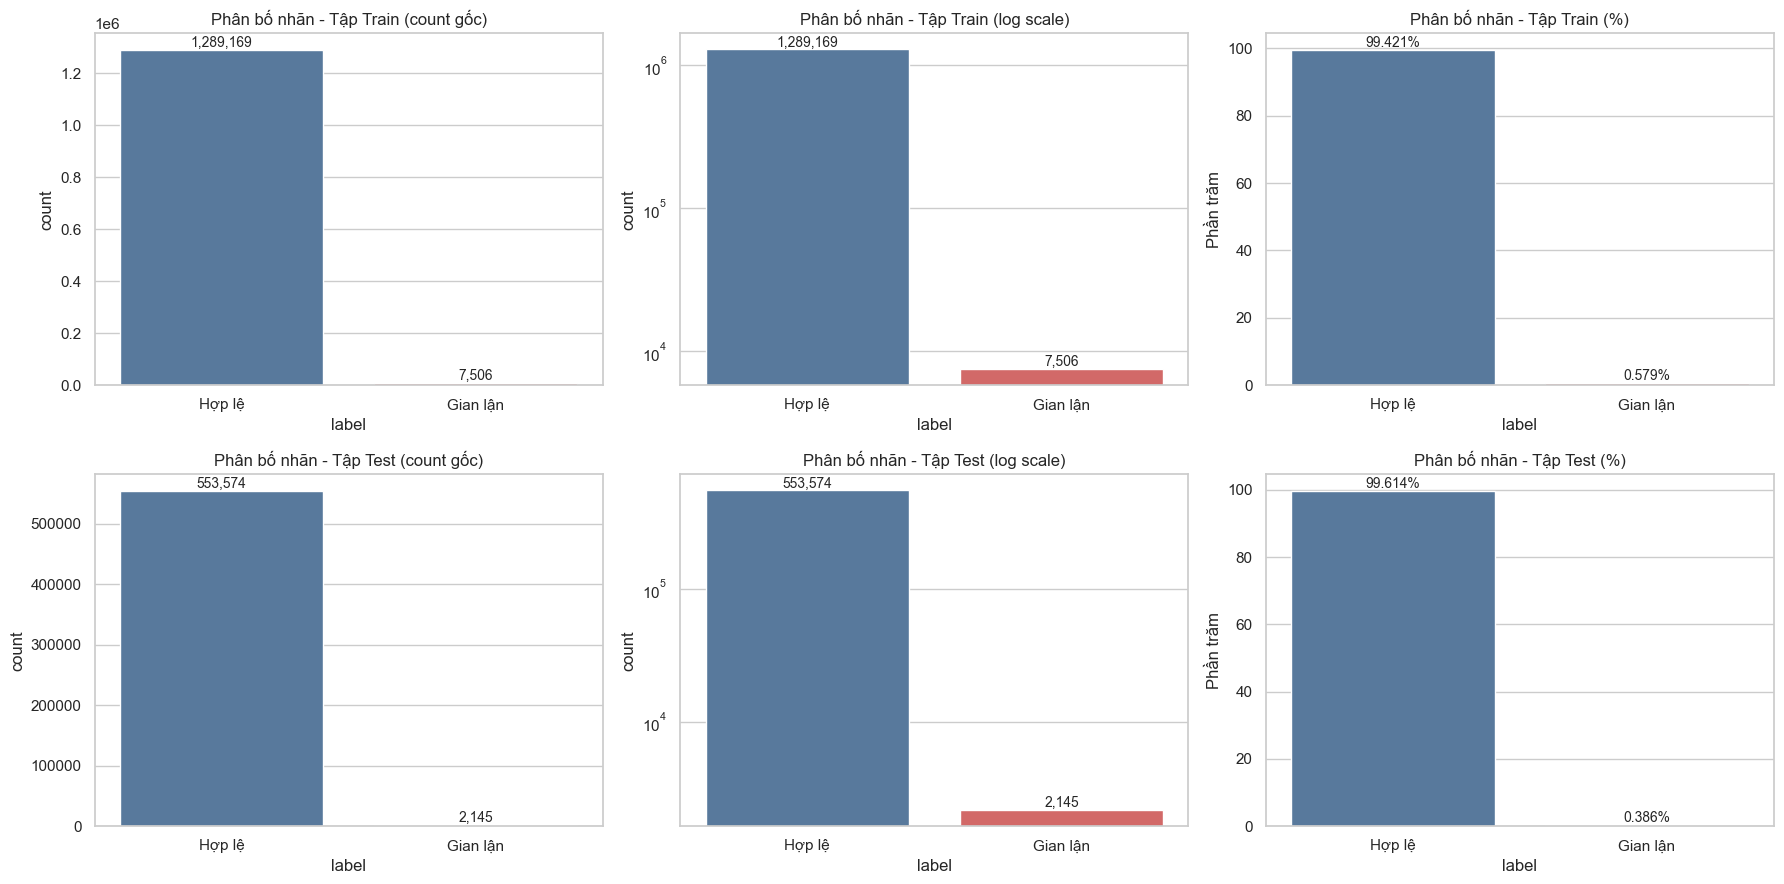

Bảng phân bố lớp - train:


,label,count,pct
0,Hợp lệ,1289169,99.421135
1,Gian lận,7506,0.578865


Bảng phân bố lớp - test:


,label,count,pct
0,Hợp lệ,553574,99.614014
1,Gian lận,2145,0.385986


In [33]:

train_counts = train_df[TARGET].value_counts().sort_index()
test_counts = test_df[TARGET].value_counts().sort_index()

train_plot = pd.DataFrame({
    'label': ['Hợp lệ', 'Gian lận'],
    'count': [train_counts.get(0, 0), train_counts.get(1, 0)],
})
train_plot['pct'] = train_plot['count'] / train_plot['count'].sum() * 100

test_plot = pd.DataFrame({
    'label': ['Hợp lệ', 'Gian lận'],
    'count': [test_counts.get(0, 0), test_counts.get(1, 0)],
})
test_plot['pct'] = test_plot['count'] / test_plot['count'].sum() * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Train
sns.barplot(data=train_plot, x='label', y='count', palette=['#4C78A8', '#E45756'], ax=axes[0, 0])
axes[0, 0].set_title('Phân bố nhãn - Tập Train (count gốc)')
for idx, row in train_plot.iterrows():
    axes[0, 0].text(idx, row['count'], f"{int(row['count']):,}", ha='center', va='bottom', fontsize=10)

sns.barplot(data=train_plot, x='label', y='count', palette=['#4C78A8', '#E45756'], ax=axes[0, 1])
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Phân bố nhãn - Tập Train (log scale)')
for idx, row in train_plot.iterrows():
    axes[0, 1].text(idx, row['count'], f"{int(row['count']):,}", ha='center', va='bottom', fontsize=10)

sns.barplot(data=train_plot, x='label', y='pct', palette=['#4C78A8', '#E45756'], ax=axes[0, 2])
axes[0, 2].set_title('Phân bố nhãn - Tập Train (%)')
axes[0, 2].set_ylabel('Phần trăm')
for idx, row in train_plot.iterrows():
    axes[0, 2].text(idx, row['pct'], f"{row['pct']:.3f}%", ha='center', va='bottom', fontsize=10)

# Test
sns.barplot(data=test_plot, x='label', y='count', palette=['#4C78A8', '#E45756'], ax=axes[1, 0])
axes[1, 0].set_title('Phân bố nhãn - Tập Test (count gốc)')
for idx, row in test_plot.iterrows():
    axes[1, 0].text(idx, row['count'], f"{int(row['count']):,}", ha='center', va='bottom', fontsize=10)

sns.barplot(data=test_plot, x='label', y='count', palette=['#4C78A8', '#E45756'], ax=axes[1, 1])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Phân bố nhãn - Tập Test (log scale)')
for idx, row in test_plot.iterrows():
    axes[1, 1].text(idx, row['count'], f"{int(row['count']):,}", ha='center', va='bottom', fontsize=10)

sns.barplot(data=test_plot, x='label', y='pct', palette=['#4C78A8', '#E45756'], ax=axes[1, 2])
axes[1, 2].set_title('Phân bố nhãn - Tập Test (%)')
axes[1, 2].set_ylabel('Phần trăm')
for idx, row in test_plot.iterrows():
    axes[1, 2].text(idx, row['pct'], f"{row['pct']:.3f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print('Bảng phân bố lớp - train:')
display(train_plot)
print('Bảng phân bố lớp - test:')
display(test_plot)


## 2.3 EDA Cơ Bản

Phần này tập trung vào các thông tin cơ bản cần có trước khi tiền xử lý sâu hơn:
- **Kiểu dữ liệu**: Phân loại cột numeric vs categorical
- **Giá trị thiếu (missing values)**: Xác định cột nào cần xử lý
- **Phân tích biến số tiền (`amt`)**: So sánh gian lận vs hợp lệ
- **Tỷ lệ fraud theo danh mục**: `category`, `state`, `gender`

In [34]:
dtype_summary = train_df.dtypes.astype(str).value_counts().rename_axis('kiểu_dữ_liệu').reset_index(name='số_cột')
missing_summary = (
    train_df.isna().sum()
    .sort_values(ascending=False)
    .rename('số_giá_trị_thiếu')
    .to_frame()
    .query('số_giá_trị_thiếu > 0')
)
amt_stats = train_df.groupby(TARGET)['amt'].describe().round(2)

# Danh mục: thêm count, fraud_count, lọc >= 100
fraud_by_category = (
    train_df.groupby('category')
    .agg({TARGET: ['sum', 'count', 'mean']})
    .droplevel(0, axis=1)
    .rename(columns={'sum': 'số_fraud', 'count': 'tổng_giao_dịch', 'mean': 'tỷ_lệ_fraud'})
    .sort_values('tỷ_lệ_fraud', ascending=False)
    .reset_index()
    .query('tổng_giao_dịch >= 100')
)

# Bang/miền: thêm count, fraud_count, lọc >= 100
fraud_by_state = (
    train_df.groupby('state')
    .agg({TARGET: ['sum', 'count', 'mean']})
    .droplevel(0, axis=1)
    .rename(columns={'sum': 'số_fraud', 'count': 'tổng_giao_dịch', 'mean': 'tỷ_lệ_fraud'})
    .sort_values('tỷ_lệ_fraud', ascending=False)
    .reset_index()
    .query('tổng_giao_dịch >= 100')
)

# Giới tính
fraud_by_gender = (
    train_df.groupby('gender')
    .agg({TARGET: ['sum', 'count', 'mean']})
    .droplevel(0, axis=1)
    .rename(columns={'sum': 'số_fraud', 'count': 'tổng_giao_dịch', 'mean': 'tỷ_lệ_fraud'})
    .reset_index()
)

print('Kiểu dữ liệu:')
display(dtype_summary)

print('Các cột có giá trị thiếu:')
display(missing_summary if not missing_summary.empty else pd.DataFrame({'thông_báo': ['Không có giá trị thiếu']}))

print('Thống kê số tiền theo nhãn:')
display(amt_stats)

print('Danh mục theo tỷ lệ gian lận (chỉ nhóm có >= 100 giao dịch):')
display(fraud_by_category)

print('Bang/miền theo tỷ lệ gian lận (chỉ nhóm có >= 100 giao dịch):')
display(fraud_by_state)

print('Tỷ lệ gian lận theo giới tính:')
display(fraud_by_gender)

Kiểu dữ liệu:


,kiểu_dữ_liệu,số_cột
0,str,12
1,int64,6
2,float64,5


Các cột có giá trị thiếu:


,thông_báo
0,Không có giá trị thiếu


Thống kê số tiền theo nhãn:


...

,category,số_fraud,tổng_giao_dịch,tỷ_lệ_fraud
0,shopping_net,1713,97543,0.017561
1,misc_net,915,63287,0.014458
2,grocery_pos,1743,123638,0.014098
3,shopping_pos,843,116672,0.007225
4,gas_transport,618,131659,0.004694
5,misc_pos,250,79655,0.003139
6,grocery_net,134,45452,0.002948
7,travel,116,40507,0.002864
8,entertainment,233,94014,0.002478
9,personal_care,220,90758,0.002424


Bang/miền theo tỷ lệ gian lận (chỉ nhóm có >= 100 giao dịch):


,state,số_fraud,tổng_giao_dịch,tỷ_lệ_fraud
1,RI,15,550,0.027273
2,AK,36,2120,0.016981
3,NV,47,5607,0.008382
4,CO,113,13880,0.008141
5,OR,149,18597,0.008012
6,TN,140,17554,0.007975
7,NE,180,24168,0.007448
8,ME,119,16505,0.007210
9,NH,59,8278,0.007127
10,OH,321,46480,0.006906


Tỷ lệ gian lận theo giới tính:


,gender,số_fraud,tổng_giao_dịch,tỷ_lệ_fraud
0,F,3735,709863,0.005262
1,M,3771,586812,0.006426


## 2.4 Làm Sạch Dữ Liệu

Phần này **kiểm tra chất lượng dữ liệu gốc** trước khi tiến hành bất kỳ biến đổi nào:

1. **Target & Duplicates**: Xác nhận biến mục tiêu có định dạng đúng, phát hiện hàng trùng lặp
2. **Missing Values**: Thống kê giá trị thiếu theo số lượng và tỷ lệ (%)
3. **Constant Columns**: Tìm cột chỉ có một giá trị duy nhất (không có thông tin phân biệt)
4. **Cardinality**: Kiểm tra số giá trị duy nhất của từng cột, phát hiện cột có quá nhiều danh mục (high cardinality) có thể gây overfitting
5. **Column Dropping Plan**: Quy định danh sách cột loại bỏ (các cột định danh mạnh như `cc_num`, `first`, `last`, v.v.)

In [35]:
# 2.4.1 Kiểm tra Target, Duplicate và Tình Trạng Dữ Liệu Gốc
print("="*80)
print("2.4 LÀM SẠCH DỮ LIỆU - KIỂM TRA CHẤT LƯỢNG DỮ LIỆU GỐC")
print("="*80)

# Target value counts
print("\n1. Kiểm tra TARGET")
print(f"Target column: {TARGET}")
print(f"Giá trị duy nhất: {train_df[TARGET].unique()}")
print(f"Value counts:\n{train_df[TARGET].value_counts(dropna=False)}")

# Duplicates
print("\n2. Kiểm tra DUPLICATE ROWS")
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()
print(f"Train duplicates: {train_duplicates} ({train_duplicates/len(train_df)*100:.2f}%)")
print(f"Test duplicates: {test_duplicates} ({test_duplicates/len(test_df)*100:.2f}%)")

# Summary table
data_quality = pd.DataFrame({
    'tập_dữ_liệu': ['train', 'test'],
    'số_dòng': [len(train_df), len(test_df)],
    'số_cột': [train_df.shape[1], test_df.shape[1]],
    'tỷ_lệ_fraud': [f"{train_df[TARGET].mean():.4%}", f"{test_df[TARGET].mean():.4%}"],
    'số_duplicate': [train_duplicates, test_duplicates],
    'tổng_missing': [train_df.isna().sum().sum(), test_df.isna().sum().sum()],
})
print("\n3. SUMMARY DỮ LIỆU GỐC")
display(data_quality)

# 2.4.2 Kiểm tra MISSING VALUES
print("\n" + "="*80)
print("4. MISSING VALUES (Giá Trị Thiếu)")
print("="*80)

def missing_table(df, name=""):
    """Tạo bảng thống kê missing values"""
    total_rows = len(df)
    missing = pd.DataFrame({
        'cột': df.columns,
        'số_missing': df.isna().sum().values,
        'tỷ_lệ_%': (df.isna().sum().values / total_rows * 100).round(2),
    })
    missing = missing[missing['số_missing'] > 0].sort_values('số_missing', ascending=False).reset_index(drop=True)
    return missing

train_missing = missing_table(train_df, "train")
test_missing = missing_table(test_df, "test")

print("\nTrain set:")
display(train_missing if not train_missing.empty else pd.DataFrame({'Thông báo': ['Không có missing values']}))

print("Test set:")
display(test_missing if not test_missing.empty else pd.DataFrame({'Thông báo': ['Không có missing values']}))

# 2.4.3 Kiểm tra CONSTANT COLUMNS (Cột Hằng)
print("\n" + "="*80)
print("5. CONSTANT COLUMNS (Cột Hằng / Chỉ 1 Giá Trị)")
print("="*80)

constant_cols = [col for col in train_df.columns if train_df[col].nunique(dropna=False) <= 1]
print(f"Constant columns: {constant_cols if constant_cols else 'Không có'}")

# 2.4.4 Kiểm tra CARDINALITY (Số Giá Trị Duy Nhất)
print("\n" + "="*80)
print("6. CARDINALITY (Số Giá Trị Duy Nhất)")
print("="*80)

cardinality = pd.DataFrame({
    'cột': train_df.columns,
    'kiểu': train_df.dtypes.astype(str).values,
    'số_giá_trị_duy_nhất': train_df.nunique(dropna=False).values,
    'tỷ_lệ_duy_nhất_%': (train_df.nunique(dropna=False) / len(train_df) * 100).round(2).values,
}).sort_values('số_giá_trị_duy_nhất', ascending=False)

print("\nTất cả cột:")
display(cardinality)

# Phát hiện HIGH CARDINALITY
high_card_threshold = 0.3  # >30% giá trị duy nhất
high_cardinality_cols = cardinality[cardinality['tỷ_lệ_duy_nhất_%'] > high_card_threshold * 100]['cột'].tolist()
print(f"\nCột HIGH CARDINALITY (>30%): {high_cardinality_cols if high_cardinality_cols else 'Không có'}")

# 2.4.5 Quy Định Danh Sách Cột Loại Bỏ
print("\n" + "="*80)
print("7. COLUMN DROPPING PLAN (Danh Sách Cột Loại Bỏ)")
print("="*80)

identifier_like_cols = [
    'Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'zip',
    'trans_num', 'unix_time', 'trans_date_trans_time', 'dob',
    'city', 'merchant'
]

drop_plan = pd.DataFrame({
    'cột': identifier_like_cols,
    'lý_do': [
        'chỉ số dòng, không có ý nghĩa dự đoán',
        'định danh thẻ, nguy cơ overfitting cao',
        'tên riêng, cardinality cao',
        'tên riêng, cardinality cao',
        'địa chỉ cụ thể, cardinality cao',
        'mã zip, tính định danh cao',
        'mã giao dịch, định danh duy nhất',
        'thời gian dạng số, được thay bằng feature đã tạo',
        'đã tách thành hour/day/month',
        'đã dùng để tạo age',
        'địa danh cụ thể, giảm tổng quát hóa',
        'tên merchant cụ thể, cardinality cao'
    ]
})

display(drop_plan)

# Kiểm tra cột nào thực sự tồn tại trong dữ liệu
existing_drop_cols = [col for col in identifier_like_cols if col in train_df.columns]
print(f"\nCột sẽ loại bỏ (tồn tại trong dữ liệu): {existing_drop_cols}")
print(f"Số cột loại bỏ: {len(existing_drop_cols)}")
print(f"Số cột giữ lại: {train_df.shape[1] - len(existing_drop_cols)}")

2.4 LÀM SẠCH DỮ LIỆU - KIỂM TRA CHẤT LƯỢNG DỮ LIỆU GỐC

1. Kiểm tra TARGET
Target column: is_fraud
Giá trị duy nhất: [0 1]
Value counts:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

2. Kiểm tra DUPLICATE ROWS
Train duplicates: 0 (0.00%)
Test duplicates: 0 (0.00%)

3. SUMMARY DỮ LIỆU GỐC


,tập_dữ_liệu,số_dòng,số_cột,tỷ_lệ_fraud,số_duplicate,tổng_missing
0,train,1296675,23,0.5789%,0,0
1,test,555719,23,0.3860%,0,0



4. MISSING VALUES (Giá Trị Thiếu)

Train set:


,Thông báo
0,Không có missing values


Test set:


...


5. CONSTANT COLUMNS (Cột Hằng / Chỉ 1 Giá Trị)
Constant columns: Không có

6. CARDINALITY (Số Giá Trị Duy Nhất)

Tất cả cột:


,cột,kiểu,số_giá_trị_duy_nhất,tỷ_lệ_duy_nhất_%
0,Unnamed: 0,int64,1296675,100.00
18,trans_num,str,1296675,100.00
21,merch_long,float64,1275745,98.39
19,unix_time,int64,1274823,98.31
1,trans_date_trans_time,str,1274791,98.31
20,merch_lat,float64,1247805,96.23
5,amt,float64,52928,4.08
2,cc_num,int64,983,0.08
9,street,str,983,0.08
12,zip,int64,970,0.07



Cột HIGH CARDINALITY (>30%): ['Unnamed: 0', 'trans_num', 'merch_long', 'unix_time', 'trans_date_trans_time', 'merch_lat']

7. COLUMN DROPPING PLAN (Danh Sách Cột Loại Bỏ)


,cột,lý_do
0,Unnamed: 0,"chỉ số dòng, không có ý nghĩa dự đoán"
1,cc_num,"định danh thẻ, nguy cơ overfitting cao"
2,first,"tên riêng, cardinality cao"
3,last,"tên riêng, cardinality cao"
4,street,"địa chỉ cụ thể, cardinality cao"
5,zip,"mã zip, tính định danh cao"
6,trans_num,"mã giao dịch, định danh duy nhất"
7,unix_time,"thời gian dạng số, được thay bằng feature đã tạo"
8,trans_date_trans_time,đã tách thành hour/day/month
9,dob,đã dùng để tạo age



Cột sẽ loại bỏ (tồn tại trong dữ liệu): ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'zip', 'trans_num', 'unix_time', 'trans_date_trans_time', 'dob', 'city', 'merchant']
Số cột loại bỏ: 12
Số cột giữ lại: 11


## 2.5 Kỹ Thuật Đặc Trưng (Feature Engineering)

Phần này **tạo các biến phụ** từ dữ liệu gốc để cải thiện khả năng dự đoán của mô hình. Mục tiêu là **biến đổi thông tin thô thành các đặc trưng có ý nghĩa** phản ánh hành vi gian lận.

#### **1. Tính Khoảng Cách Địa Lý - Công Thức Haversine**

**Vì sao?** Gian lận nhanh (velocity fraud) xảy ra khi khách hàng giao dịch ở hai địa điểm xa nhau trong thời gian rất ngắn. 

**Ví dụ:** Khách hàng sống ở TP.HCM nhưng 30 phút sau có giao dịch ở Hà Nội (cách nhau ~1650 km) → không khả thi → dấu hiệu gian lận rõ ràng.

**Công Thức Haversine:**

Cho hai điểm trên Trái Đất có tọa độ $(lat_1, lon_1)$ và $(lat_2, lon_2)$:

$$a = \sin^2\left(\frac{\Delta \text{lat}}{2}\right) + \cos(\text{lat}_1) \cdot \cos(\text{lat}_2) \cdot \sin^2\left(\frac{\Delta \text{lon}}{2}\right)$$

$$c = 2 \arctan2\left(\sqrt{a}, \sqrt{1-a}\right)$$

$$d = R \cdot c$$

Trong đó:
- $\Delta \text{lat} = \text{lat}_2 - \text{lat}_1$, $\Delta \text{lon} = \text{lon}_2 - \text{lon}_1$ (chuyển sang radian)
- $R = 6371$ km (bán kính Trái Đất)
- $d$ là khoảng cách đường chim bay (km)

**Tại sao Haversine thay vì Euclidean?** 
- Euclidean tính trên mặt phẳng, không tính đến độ cong của Trái Đất → kết quả sai
- Haversine là công thức chuẩn cho khoảng cách trên **hình cầu** → **chính xác hơn**

#### **2. Các Feature Về Thời Gian**

- **`hour`** (0-23): Giờ trong ngày
  - Gian lận thường xảy ra ngoài giờ làm việc (đêm khuya, sáng sớm)
  - Ví dụ: Giao dịch lúc 3:00 AM có độ rủi ro cao hơn lúc 2:00 PM

- **`dayofweek`** (0=Thứ 2, ..., 6=Chủ Nhật): Ngày trong tuần
  - Hành vi giao dịch khác biệt giữa **weekday vs weekend**
  - Ví dụ: Chủ Nhật có thể có nhiều hoạt động bất thường hơn

- **`month`** (1-12): Tháng trong năm
  - Dịp lễ, kỳ nghỉ có tỷ lệ gian lận cao hơn
  - Ví dụ: Tháng 12 (Black Friday, Giáng Sinh) có nhiều giao dịch bất thường

- **`is_weekend`** (0/1): Biến nhị phân
  - 1 nếu thứ 6-7 (weekend), 0 nếu weekday
  - Dễ dàng để mô hình tree-based xuất hiện trong bảng quyết định

#### **3. Tuổi (`age`)**

**Công Thức:**
$$\text{age} = \frac{\text{days between transaction and DOB}}{365.25}$$

- Tính tuổi tại thời điểm giao dịch (từ `dob` đến `trans_date_trans_time`)
- **Người trẻ vs người già có hành vi giao dịch khác nhau**
- Gian lận có thể lệch theo nhóm tuổi (ví dụ: thanh niên có thể bị hack tài khoản nhiều hơn)

#### **4. Log Transformation của Số Tiền (`amt_log`)**

**Công Thức:**
$$\text{amt\_log} = \log(1 + \text{amt})$$

- Số tiền giao dịch thường có **phân bố lệch phải (right-skewed)** → có nhiều giao dịch nhỏ, ít giao dịch lớn
- **Log-transform** giúp làm dữ liệu **hơn, gần phân bố bình thường** → mô hình học tốt hơn
- **Cộng 1** (log1p) để tránh `log(0)` khi amount = 0
- **Hiệu ứng**: Giãn các giá trị nhỏ, nén các giá trị lớn → dễ so sánh hơn

In [36]:

def haversine_np(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return 6371.0 * c

def add_eda_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

    df["hour"] = df["trans_date_trans_time"].dt.hour
    df["dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
    df["month"] = df["trans_date_trans_time"].dt.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    age_days = (df["trans_date_trans_time"] - df["dob"]).dt.days
    df["age"] = (age_days / 365.25).clip(lower=0)
    df["distance_km"] = haversine_np(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
    df["amt_log"] = np.log1p(df["amt"])
    return df

eda_train = add_eda_features(train_df)
eda_test = add_eda_features(test_df)

print("Hình dạng TRAIN sau EDA feature:", eda_train.shape)
print("Hình dạng TEST sau EDA feature: ", eda_test.shape)
eda_train[["trans_date_trans_time", "hour", "dayofweek", "month", "age", "distance_km", "amt_log"]].head(3)

Hình dạng TRAIN sau EDA feature: (1296675, 30)
Hình dạng TEST sau EDA feature:  (555719, 30)


,trans_date_trans_time,hour,dayofweek,month,age,distance_km,amt_log
0,2019-01-01 00:00:18,0,1,1,30.814511,78.597568,1.786747
1,2019-01-01 00:00:44,0,1,1,40.531143,30.212176,4.684259
2,2019-01-01 00:00:51,0,1,1,56.950034,108.206083,5.398660


### Phân Tích Chi Tiết

Dùng các features vừa tạo để phân tích:
- Phân bố số tiền sau log-transform (so sánh gian lận vs hợp lệ)
- Tỷ lệ fraud theo giờ trong ngày (gian lận có mô hình thời gian?)
- Tỷ lệ fraud theo ngày trong tuần (weekday vs weekend khác biệt?)
- Top 10 danh mục (`category`) theo tỷ lệ gian lận
- Mối quan hệ giữa khoảng cách địa lý và gian lận (distance_km)
- Top 10 bang/miền (`state`) theo tỷ lệ gian lận

Phan EDA mo rong duoc tach thanh 6 cell rieng, moi cell mot bieu do. Cach trinh bay nay de doc hon, de chup hinh dua vao bao cao hon, va de viet nhan xet sau tung bieu do.


### 2.5.1 Phân bố số tiền sau log transformation

Biểu đồ này giúp quan sát sự khác biệt phân phối `amt_log` giữa giao dịch hợp lệ và gian lận.


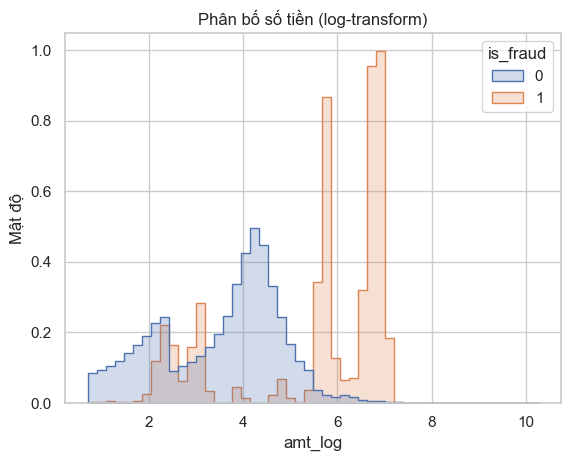

In [37]:

sns.histplot(
    data=eda_train,
    x="amt_log",
    hue=TARGET,
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Phân bố số tiền (log-transform)")
plt.xlabel("amt_log")
plt.ylabel("Mật độ")
plt.show()


### 2.5.2 Tỷ lệ gian lận theo giờ trong ngày

Biểu đồ này cho thấy thời điểm nào trong ngày có xu hướng xuất hiện fraud cao hơn.


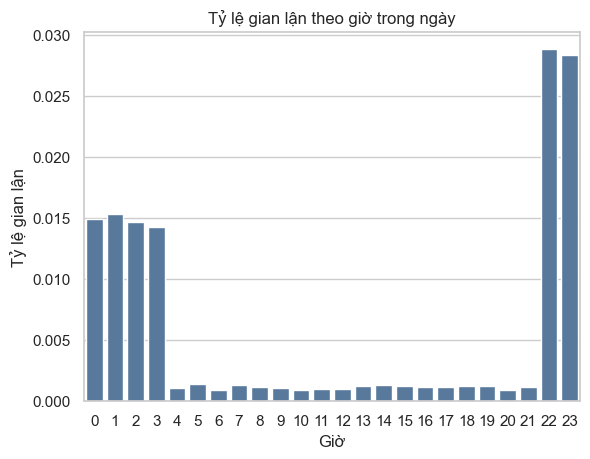

In [38]:

hourly = eda_train.groupby("hour")[TARGET].mean().reset_index()
sns.barplot(data=hourly, x="hour", y=TARGET, color="#4C78A8")
plt.title("Tỷ lệ gian lận theo giờ trong ngày")
plt.ylabel("Tỷ lệ gian lận")
plt.xlabel("Giờ")
plt.show()


### 2.5.3 Tỷ lệ gian lận theo ngày trong tuần

Biểu đồ này hỗ trợ kiểm tra xem fraud có khác biệt giữa ngày làm việc và cuối tuần hay không.


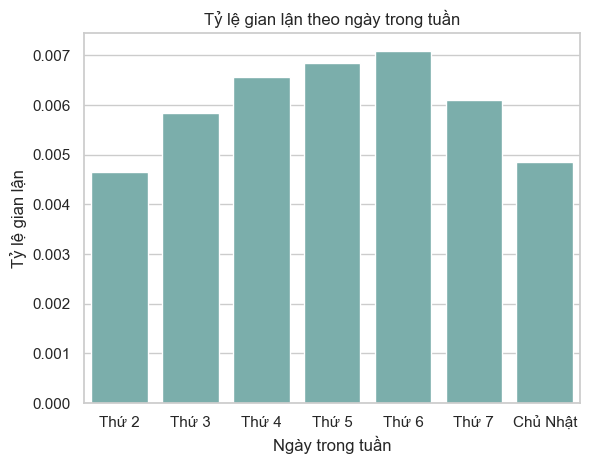

In [39]:

day_labels = ["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "Chủ Nhật"]
dayofweek = eda_train.groupby("dayofweek")[TARGET].mean().reset_index()
sns.barplot(data=dayofweek, x="dayofweek", y=TARGET, color="#72B7B2")
plt.title("Tỷ lệ gian lận theo ngày trong tuần")
plt.ylabel("Tỷ lệ gian lận")
plt.xlabel("Ngày trong tuần")
plt.xticks(ticks=range(7), labels=day_labels)
plt.show()


### 2.5.4 Top danh mục theo tỷ lệ gian lận

Biểu đồ này cho thấy những `category` nào có tỷ lệ fraud cao nhất. Khi phân tích, nên đọc cùng với số lượng giao dịch để tránh kết luận lệch do nhóm quá nhỏ.


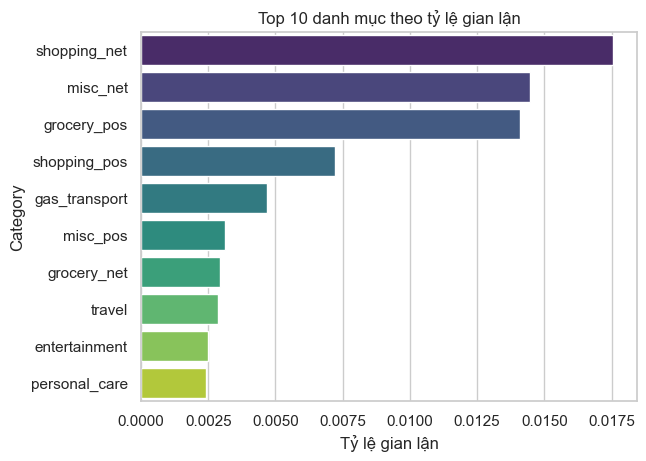

In [40]:

top_categories = (
    eda_train.groupby("category")[TARGET]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
sns.barplot(data=top_categories, y="category", x=TARGET, palette="viridis")
plt.title("Top 10 danh mục theo tỷ lệ gian lận")
plt.xlabel("Tỷ lệ gian lận")
plt.ylabel("Category")
plt.show()


### 2.5.5 Khoảng cách đến merchant so với nhãn

Boxplot này dùng để xem các giao dịch gian lận có xu hướng xảy ra khi khoảng cách từ chủ thẻ đến merchant lớn hơn hay không.


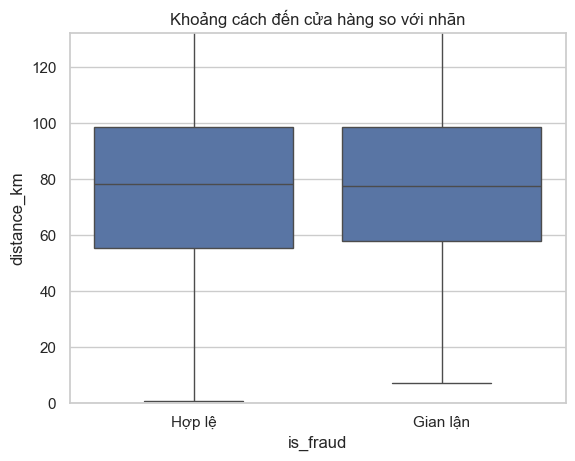

In [41]:

sample_size = min(len(eda_train), 50000)
sns.boxplot(
    data=eda_train.sample(sample_size, random_state=RANDOM_STATE),
    x=TARGET,
    y="distance_km",
)
plt.title("Khoảng cách đến cửa hàng so với nhãn")
plt.xticks([0, 1], ["Hợp lệ", "Gian lận"])
plt.ylim(0, np.nanpercentile(eda_train["distance_km"], 99))
plt.show()


### 2.5.6 Top bang/miền theo tỷ lệ gian lận

Biểu đồ này giúp xác định các `state` có tỷ lệ fraud cao. Tương tự phần category, nên đọc cùng số lượng giao dịch của từng bang.


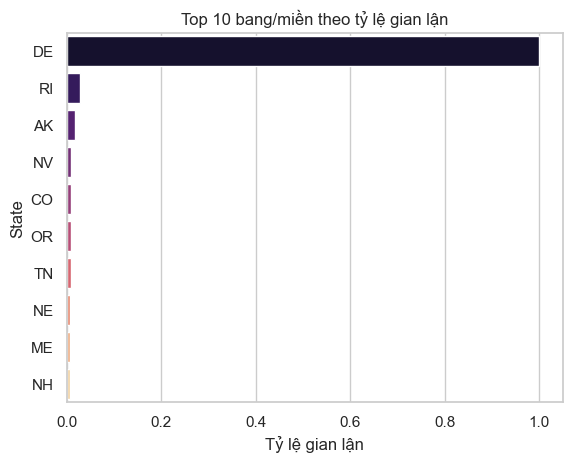

In [42]:

top_states = (
    eda_train.groupby("state")[TARGET]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
sns.barplot(data=top_states, y="state", x=TARGET, palette="magma")
plt.title("Top 10 bang/miền theo tỷ lệ gian lận")
plt.xlabel("Tỷ lệ gian lận")
plt.ylabel("State")
plt.show()


## 2.6 Lựa Chọn Đặc Trưng (Feature Selection)

Phần này **đánh giá tầm quan trọng** của từng đặc trưng để quyết định giữ hoặc loại bỏ:

1. **Tương Quan (Correlation)**: Kiểm tra độ tương quan tuyến tính giữa các biến số và target
   - Biến nào có tương quan cao với target → có khả năng dự đoán tốt
   - Biến nào tương quan thấp → có thể loại bỏ (nhưng không phải lúc nào cũng đúng - đặc biệt với non-linear relationship)

2. **Thông Tin Lẫn Nhau (Mutual Information)**: Đo mức độ phụ thuộc (cả tuyến tính lẫn phi tuyến) giữa biến và target
   - Cao hơn correlation vì bắt được các mối quan hệ phi tuyến
   - Phù hợp cho **cả biến số lẫn categorical**

3. **Feature Importance từ Tree Models**: Tree-based models (Random Forest, Extra Trees) tự động xác định tầm quan trọng của từng feature
   - Dựa trên **số lần feature được dùng để chia nhánh** (split) và **mức độ giảm entropy/Gini**
   - Nắm bắt **non-linear relationships** tốt hơn

**Lưu ý:** Một biến có tương quan thấp nhưng MI cao (hoặc importance cao) có thể vẫn hữu ích → không nên loại bỏ quá sớm.

In [43]:
# 2.6.1 Tương Quan (Correlation) giữa biến số và target
numeric_cols = eda_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != TARGET]

correlation = eda_train[numeric_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
corr_df = correlation.reset_index().rename(columns={'index': 'cột', TARGET: 'tương_quan_với_target'})

print("Tương quan giữa biến số và target:")
display(corr_df)

Tương quan giữa biến số và target:


,cột,tương_quan_với_target
0,amt,0.219404
1,amt_log,0.120439
2,hour,0.013799
3,month,-0.012409
4,age,0.012270
5,unix_time,-0.005078
6,Unnamed: 0,-0.004767
7,is_weekend,-0.003644
8,zip,-0.002162
9,city_pop,0.002136


In [44]:
# 2.6.2 Thông Tin Lẫn Nhau (Mutual Information)
from sklearn.feature_selection import mutual_info_classif
from pandas.api.types import is_numeric_dtype, is_datetime64_any_dtype, is_bool_dtype

# Chuẩn bị dữ liệu: encode categorical, handle missing theo đúng kiểu dữ liệu
X_mi = eda_train.drop(columns=[TARGET]).copy()
y_mi = eda_train[TARGET].copy()

X_mi_encoded = pd.DataFrame(index=X_mi.index)
for col in X_mi.columns:
    series = X_mi[col].copy()

    if is_datetime64_any_dtype(series):
        fill_value = series.dropna().median() if not series.dropna().empty else pd.Timestamp('1970-01-01')
        series = series.fillna(fill_value).astype('int64')
    elif is_bool_dtype(series):
        series = series.fillna(False).astype(int)
    elif is_numeric_dtype(series):
        fill_value = series.dropna().median() if not series.dropna().empty else 0
        series = series.fillna(fill_value)
    else:
        series = series.fillna('Missing').astype('string')
        series = pd.Categorical(series).codes

    X_mi_encoded[col] = series

# Tính MI
mi_scores = mutual_info_classif(X_mi_encoded, y_mi, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    'cột': X_mi.columns,
    'mutual_information': mi_scores
}).sort_values('mutual_information', ascending=False)

print()
print("Thông Tin Lẫn Nhau (Mutual Information) với target:")
display(mi_df)


Thông Tin Lẫn Nhau (Mutual Information) với target:


,cột,mutual_information
8,gender,0.128003
25,is_weekend,0.086963
23,dayofweek,0.047844
4,category,0.025405
24,month,0.024646
22,hour,0.019325
28,amt_log,0.017411
5,amt,0.017387
26,age,0.016740
11,state,0.010321


In [45]:
# 2.6.3 (Đã bỏ) Feature Importance từ Random Forest
print("Đã bỏ bước Feature Importance bằng Random Forest vì nhầm lẫn với preprocessing.")

Đã bỏ bước Feature Importance bằng Random Forest vì nhầm lẫn với preprocessing.


In [46]:

# 2.6.4 Tóm tắt (ranking)
print()
print("="*80)
print("TÓM TẮT LỰA CHỌN ĐẶC TRƯNG")
print("="*80)

ranking_df = pd.DataFrame({'cột': X_mi.columns})
ranking_df['rank_correlation'] = ranking_df['cột'].map(lambda x: corr_df[corr_df['cột']==x].index[0] if x in corr_df['cột'].values else len(corr_df))
ranking_df['rank_mi'] = ranking_df['cột'].map(lambda x: mi_df[mi_df['cột']==x].index[0] if x in mi_df['cột'].values else len(mi_df))

ranking_df['trung_bình_rank'] = ranking_df[['rank_correlation', 'rank_mi']].mean(axis=1)
ranking_df = ranking_df.sort_values('trung_bình_rank').reset_index(drop=True)

summary_ranking = ranking_df[['cột', 'rank_correlation', 'rank_mi', 'trung_bình_rank']].head(20)
display(summary_ranking.rename(columns={
    'rank_correlation': 'xếp_hạng_correlation',
    'rank_mi': 'xếp_hạng_MI',
    'trung_bình_rank': 'TBxếp_hạng'
}))

print()
print("Nhận xét:")
print("- Features đứng đầu theo correlation + MI (xếp hạng thấp) được coi là quan trọng hơn")
print("- Features đứng cuối (xếp hạng cao) có thể cân nhắc loại bỏ")
print("- Khi mô phỏng mô hình, có thể thử các tập con features khác nhau để tối ưu hóa hiệu suất")



TÓM TẮT LỰA CHỌN ĐẶC TRƯNG


,cột,xếp_hạng_correlation,xếp_hạng_MI,TBxếp_hạng
0,amt,0,5,2.5
1,Unnamed: 0,6,0,3.0
2,cc_num,15,2,8.5
3,trans_date_trans_time,17,1,9.0
4,merchant,17,3,10.0
5,zip,8,12,10.0
6,category,17,4,10.5
7,first,17,6,11.5
8,lat,10,13,11.5
9,hour,2,22,12.0



Nhận xét:
- Features đứng đầu theo correlation + MI (xếp hạng thấp) được coi là quan trọng hơn
- Features đứng cuối (xếp hạng cao) có thể cân nhắc loại bỏ
- Khi mô phỏng mô hình, có thể thử các tập con features khác nhau để tối ưu hóa hiệu suất


## 2.7 Tiền Xử Lý Chính Thức & Mã Hóa, Chuẩn Hóa (Preprocessing & Encoding/Scaling)

Phần này thực hiện **tiền xử lý chính thức cho mô hình học máy**:

1. **Kiểm tra target và duplicate**: Xác nhận biến mục tiêu đúng định dạng, phát hiện hàng trùng lặp
2. **Kiểm tra giá trị thiếu**: Thống kê missing values theo số lượng và tỷ lệ (%)
3. **Kiểm tra cột hằng / cột thông tin ít**: Tìm cột có chỉ một giá trị hoặc cardinality rất thấp
4. **Quy định danh sách cột loại bỏ**: Các cột định danh mạnh như `cc_num`, `first`, `last`, v.v.
5. **Tạo feature cho mô hình**: Đặc biệt là feature liên quan đến thời gian, vị trí, tuổi (như đã làm ở 2.5)
6. **Kiểm tra lại dữ liệu sau khi biến đổi**: Đảm bảo không có missing/constant columns mới
7. **Xác định nhóm feature**: Chia thành numeric vs categorical
8. **Tạo preprocessing pipeline**: Impute, Scale (numeric) + Impute, OneHotEncode (categorical)
9. **Chia train-validation-test**: Stratified split để giữ tỷ lệ fraud

**Lưu ý quan trọng:** Nếu bạn đã lựa chọn loại bỏ một số features ở bước 2.6, bạn nên cập nhật danh sách `identifier_like_cols` hoặc `drop_cols` để phản ánh quyết định đó.

In [47]:

# 7.1 Kiểm tra target, duplicate và tình trạng dữ liệu gốc trước modeling
pre_model_summary = pd.DataFrame({
    'chỉ_số': [
        'số_dòng_train', 'số_dòng_test',
        'tỷ_lệ_fraud_train', 'tỷ_lệ_fraud_test',
        'số_dòng_trùng_train', 'số_dòng_trùng_test'
    ],
    'giá_trị': [
        len(train_df), len(test_df),
        train_df[TARGET].mean(), test_df[TARGET].mean(),
        train_df.duplicated().sum(), test_df.duplicated().sum()
    ]
})
display(pre_model_summary)

print('Phân bố target - Tập train:')
display(train_df[TARGET].value_counts(dropna=False).rename_axis('nhãn').reset_index(name='số_lượng'))
print('Phân bố target - Tập test:')
display(test_df[TARGET].value_counts(dropna=False).rename_axis('nhãn').reset_index(name='số_lượng'))

,chỉ_số,giá_trị
0,số_dòng_train,1.296675e+06
1,số_dòng_test,5.557190e+05
2,tỷ_lệ_fraud_train,5.788652e-03
3,tỷ_lệ_fraud_test,3.859864e-03
4,số_dòng_trùng_train,0.000000e+00
5,số_dòng_trùng_test,0.000000e+00


Phân bố target - Tập train:


,nhãn,số_lượng
0,0,1289169
1,1,7506


Phân bố target - Tập test:


,nhãn,số_lượng
0,0,553574
1,1,2145


Bước này xác nhận:
- Biến mục tiêu (`is_fraud`) có phân bố đúng (0 = hợp lệ, 1 = gian lận)
- Tỷ lệ gian lận trên train vs test có consistent không
- Có bao nhiêu hàng trùng lặp?

Trong fraud detection, nếu có quá nhiều duplicate vừa xuất hiện trên train vừa trên test, điều này có thể làm sai lệch đánh giá (mô hình nhớ các giao dịch trùng = không tổng quát hóa).

In [48]:

# 2.7.2 Kiểm tra giá trị thiếu trên dữ liệu gốc
def missing_table(df: pd.DataFrame) -> pd.DataFrame:
    """Tạo bảng thống kê giá trị thiếu"""
    total_rows = len(df)
    tbl = (
        df.isna().sum()
        .rename('số_giá_trị_thiếu')
        .to_frame()
        .assign(tỷ_lệ_phần_trăm=lambda x: x['số_giá_trị_thiếu'] / total_rows * 100)
        .sort_values(['số_giá_trị_thiếu', 'tỷ_lệ_phần_trăm'], ascending=False)
    )
    return tbl.query('số_giá_trị_thiếu > 0')

train_missing_raw = missing_table(train_df)
test_missing_raw = missing_table(test_df)

print('Tóm tắt giá trị thiếu - Tập train:')
display(train_missing_raw.head(20) if not train_missing_raw.empty else pd.DataFrame({'thông_báo': ['Không có giá trị thiếu']}))

print('Tóm tắt giá trị thiếu - Tập test:')
display(test_missing_raw.head(20) if not test_missing_raw.empty else pd.DataFrame({'thông_báo': ['Không có giá trị thiếu']}))

Tóm tắt giá trị thiếu - Tập train:


,thông_báo
0,Không có giá trị thiếu


Tóm tắt giá trị thiếu - Tập test:


,thông_báo
0,Không có giá trị thiếu


Ta thống kê missing theo số lượng và tỷ lệ (%). 

**Chiến lược xử lý missing:**
- **Đối với biến numeric**: Dùng `SimpleImputer(strategy='median')` - thay thế giá trị thiếu bằng median (không bị ảnh hưởng bởi outliers)
- **Đối với biến categorical**: Dùng `SimpleImputer(strategy='most_frequent')` - thay thế bằng giá trị xuất hiện nhiều nhất

Chúng tôi không xóa hàng vì:
1. Số lượng cột không quá lớn
2. Y nghĩa nghiệp vụ của dữ liệu vẫn có thể hữu ích dù thiếu vài giá trị
3. Preprocessing pipeline sẽ tự động xử lý, không cần can thiệp thủ công

In [49]:

# 2.7.3 Kiểm tra cột hằng, độ đa dạng thấp và cardinality của biến phân loại
raw_single_value_cols = [col for col in train_df.columns if train_df[col].nunique(dropna=False) <= 1]
low_variance_preview = (
    train_df.nunique(dropna=False)
    .sort_values()
    .rename('số_giá_trị_duy_nhất')
    .reset_index()
    .rename(columns={'index': 'cột'})
)
categorical_cardinality = (
    train_df.select_dtypes(include=['object'])
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .rename('số_giá_trị_duy_nhất')
    .reset_index()
    .rename(columns={'index': 'cột'})
)

print('Cột hằng (không cung cấp thông tin):')
display(pd.DataFrame({'cột': raw_single_value_cols}) if raw_single_value_cols else pd.DataFrame({'thông_báo': ['Không có cột hằng']}))

print('Các cột có số giá trị duy nhất thấp nhất:')
display(low_variance_preview.head(15))

print('Cardinality của các cột biến loại:')
display(categorical_cardinality)

Cột hằng (không cung cấp thông tin):


,thông_báo
0,Không có cột hằng


Các cột có số giá trị duy nhất thấp nhất:


,cột,số_giá_trị_duy_nhất
0,is_fraud,2
1,gender,2
2,category,14
3,state,51
4,first,352
5,last,481
6,job,494
7,merchant,693
8,city_pop,879
9,city,894


Cardinality của các cột biến loại:


,cột,số_giá_trị_duy_nhất
0,trans_num,1296675
1,trans_date_trans_time,1274791
2,street,983
3,dob,968
4,city,894
5,merchant,693
6,job,494
7,last,481
8,first,352
9,state,51


Bước này giúp phát hiện:

1. **Cột hằng (constant columns)**: Chỉ có một giá trị duy nhất → không cung cấp thông tin → loại bỏ
2. **Cột phương sai thấp (low variance)**: Có rất ít giá trị duy nhất → ít thông tin phân biệt → cần xem xét loại bỏ
3. **Cardinality cao (high cardinality)**: Biến categorical có quá nhiều giá trị (e.g., `merchant` có 600+ giá trị) → khi one-hot encode sẽ tạo 600+ cột mới → gây:
   - Sparse matrix (ma trận thưa thớt)
   - Overfitting (mô hình nhớ thay vì học mô hình)
   - Tăng chi phí tính toán và bộ nhớ

**Ví dụ:** Cột `merchant` có ~600 merchant khác nhau. Nếu dùng one-hot encoding, sẽ tạo 600 cột mới (mỗi cột là 0/1 cho một merchant). Vì rất ít giao dịch per merchant, mô hình dễ overfit hơn là học mô hình chung.

In [50]:

# 2.7.4 Quy định danh sách cột loại bỏ cho modeling
identifier_like_cols = [
    'Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'zip',
    'trans_num', 'unix_time', 'trans_date_trans_time', 'dob',
    'city', 'merchant'
]
drop_reason_df = pd.DataFrame({
    'cột': identifier_like_cols,
    'lý_do_loại_bỏ': [
        'chỉ số dòng, không có ý nghĩa dự đoán',
        'định danh thẻ, nguy cơ overfitting cao',
        'tên riêng, cardinality cao',
        'tên riêng, cardinality cao',
        'địa chỉ cụ thể, cardinality cao',
        'mã zip, tính định danh cao',
        'mã giao dịch, định danh duy nhất',
        'thời gian dạng số, được thay bằng feature đã tạo',
        'đã tách thành hour/day/month',
        'đã dùng để tạo age',
        'địa danh cụ thể, giảm tổng quát hóa',
        'tên merchant cụ thể, cardinality cao'
    ]
})
display(drop_reason_df)

,cột,lý_do_loại_bỏ
0,Unnamed: 0,"chỉ số dòng, không có ý nghĩa dự đoán"
1,cc_num,"định danh thẻ, nguy cơ overfitting cao"
2,first,"tên riêng, cardinality cao"
3,last,"tên riêng, cardinality cao"
4,street,"địa chỉ cụ thể, cardinality cao"
5,zip,"mã zip, tính định danh cao"
6,trans_num,"mã giao dịch, định danh duy nhất"
7,unix_time,"thời gian dạng số, được thay bằng feature đã tạo"
8,trans_date_trans_time,đã tách thành hour/day/month
9,dob,đã dùng để tạo age


Chúng tôi cẩn thận khi xử lý cột:

- **Loại bỏ cột định danh mạnh**: `cc_num`, `first`, `last`, `street`, `zip`, `trans_num`, `unix_time` vì:
  - Số từ định danh duy nhất → nguy cơ overfitting cao
  - Không phản ánh mô hình hành vi chung
  
- **Giữ lại cột categorical có ý nghĩa**: `category` (loại giao dịch), `job` (nghề nghiệp), `state` (bang/miền), `gender` (giới tính) vì:
  - Số giá trị hợp lý (15-50)
  - Có ý nghĩa nghiệp vụ rõ ràng
  - Gian lận có thể khác biệt theo loại danh mục (e.g., gas station có risk cao hơn grocery)
  - Mô hình sẽ học được mô hình hành vi per category

In [51]:

# 2.7.5 Tạo feature cho modeling
def add_model_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tạo tất cả feature cho modeling, sau đó loại bỏ cột định danh"""
    df = add_eda_features(df)
    return df.drop(columns=identifier_like_cols, errors='ignore')

train_fe = add_model_features(train_df)
test_fe = add_model_features(test_df)

print('Hình dạng sau feature engineering - train:', train_fe.shape)
print('Hình dạng sau feature engineering - test: ', test_fe.shape)
display(train_fe.head(3))

Hình dạng sau feature engineering - train: (1296675, 18)
Hình dạng sau feature engineering - test:  (555719, 18)


,category,amt,gender,state,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,dayofweek,month,is_weekend,age,distance_km,amt_log
0,misc_net,4.97,F,NC,36.0788,-81.1781,3495,"Psychologist, counselling",36.011293,-82.048315,0,0,1,1,0,30.814511,78.597568,1.786747
1,grocery_pos,107.23,F,WA,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0,0,1,1,0,40.531143,30.212176,4.684259
2,entertainment,220.11,M,ID,42.1808,-112.2620,4154,Nature conservation officer,43.150704,-112.154481,0,0,1,1,0,56.950034,108.206083,5.398660


In [52]:

# 2.7.6 Kiểm tra lại dữ liệu sau feature engineering
train_missing_fe = missing_table(train_fe)
test_missing_fe = missing_table(test_fe)
single_value_fe = [col for col in train_fe.columns if train_fe[col].nunique(dropna=False) <= 1 and col != TARGET]

print('Giá trị thiếu sau feature engineering - train:')
display(train_missing_fe if not train_missing_fe.empty else pd.DataFrame({'thông_báo': ['Không có giá trị thiếu']}))

print('Giá trị thiếu sau feature engineering - test:')
display(test_missing_fe if not test_missing_fe.empty else pd.DataFrame({'thông_báo': ['Không có giá trị thiếu']}))

print('Cột hằng sau feature engineering:')
display(pd.DataFrame({'cột': single_value_fe}) if single_value_fe else pd.DataFrame({'thông_báo': ['Không có cột hằng']}))

if single_value_fe:
    train_fe = train_fe.drop(columns=single_value_fe, errors='ignore')
    test_fe = test_fe.drop(columns=single_value_fe, errors='ignore')
    print('Đã loại bỏ các cột hằng sau feature engineering.')

Giá trị thiếu sau feature engineering - train:


,thông_báo
0,Không có giá trị thiếu


Giá trị thiếu sau feature engineering - test:


,thông_báo
0,Không có giá trị thiếu


Cột hằng sau feature engineering:


,thông_báo
0,Không có cột hằng


### 2.7.6 Nhận Xét

**Tại sao kiểm tra lại?**
- Sau khi tạo feature (hour, age, distance, v.v.), có thể phát sinh missing mới
  - Ví dụ: `age` sẽ là NaN nếu `dob` = NaN
  - Ví dụ: `distance_km` sẽ là NaN nếu lat/long = NaN
- Cột hằng có thể xuất hiện sau drop
  
Đảm bảo dữ liệu sạch trước khi đưa vào mô hình là bước quan trọng.

In [53]:

# 2.7.7 Tách X/y, chia train-validation và tiền xử lý thành dữ liệu số
X_full = train_fe.drop(columns=[TARGET])
y_full = train_fe[TARGET]
X_test = test_fe.drop(columns=[TARGET])
y_test = test_fe[TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=RANDOM_STATE,
)

# Chỉ định rõ các cột cần transform
categorical_features = ['category', 'gender', 'state', 'job']
numeric_features = [
    'amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long',
    'hour', 'dayofweek', 'month', 'is_weekend', 'age', 'distance_km', 'amt_log'
]

# Kiểm tra nhanh cột trước khi transform
missing_num = [c for c in numeric_features if c not in X_train.columns]
missing_cat = [c for c in categorical_features if c not in X_train.columns]
if missing_num or missing_cat:
    raise ValueError(f'Thiếu cột. Numeric: {missing_num}; Categorical: {missing_cat}')

# Pipeline cho numeric: điền thiếu + chuẩn hóa
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Pipeline cho categorical: điền thiếu + one-hot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# Gộp hai nhánh transform theo tên cột
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop',
)

# Fit trên train, transform cho valid/test để tránh leakage
X_train_prepared = preprocessor.fit_transform(X_train)
X_valid_prepared = preprocessor.transform(X_valid)
X_test_prepared = preprocessor.transform(X_test)
feature_names_after_prep = preprocessor.get_feature_names_out()

feature_group_df = pd.DataFrame({
    'nhóm': ['numeric', 'categorical'],
    'số_lượng': [len(numeric_features), len(categorical_features)],
    'ví_dụ': [', '.join(numeric_features[:8]), ', '.join(categorical_features[:8])]
})
display(feature_group_df)

print('Hình dạng tập chia:')
print(f'  Train: X={X_train.shape}, y={y_train.shape}')
print(f'  Validation: X={X_valid.shape}, y={y_valid.shape}')
print(f'  Test: X={X_test.shape}, y={y_test.shape}')
print('\nHình dạng sau preprocessing:')
print(f'  X_train_prepared: {X_train_prepared.shape}')
print(f'  X_valid_prepared: {X_valid_prepared.shape}')
print(f'  X_test_prepared: {X_test_prepared.shape}')
print(f'  Số feature sau one-hot + scale: {len(feature_names_after_prep)}')

# Lưu dữ liệu đã chia ra CSV để lần sau train không cần chạy lại các cell phía trên
processed_dir = ARTIFACT_DIR / 'processed_csv'
processed_dir.mkdir(parents=True, exist_ok=True)

X_train.to_csv(processed_dir / 'X_train.csv', index=False)
X_valid.to_csv(processed_dir / 'X_valid.csv', index=False)
X_test.to_csv(processed_dir / 'X_test.csv', index=False)

y_train.to_frame(name=TARGET).to_csv(processed_dir / 'y_train.csv', index=False)
y_valid.to_frame(name=TARGET).to_csv(processed_dir / 'y_valid.csv', index=False)
y_test.to_frame(name=TARGET).to_csv(processed_dir / 'y_test.csv', index=False)

print(f"\nĐã lưu CSV tại: {processed_dir.resolve()}")

,nhóm,số_lượng,ví_dụ
0,numeric,13,"amt, lat, long, city_pop, merch_lat, merch_lon..."
1,categorical,4,"category, gender, state, job"


Hình dạng tập chia:
  Train: X=(1037340, 17), y=(1037340,)
  Validation: X=(259335, 17), y=(259335,)
  Test: X=(555719, 17), y=(555719,)

Hình dạng sau preprocessing:
  X_train_prepared: (1037340, 574)
  X_valid_prepared: (259335, 574)
  X_test_prepared: (555719, 574)
  Số feature sau one-hot + scale: 574

Đã lưu CSV tại: D:\Project\DataMining-DataWarehouse\Source\artifacts\processed_csv


### 2.7.7.a Danh sách cột cuối cùng dùng cho modeling

Cell này in ra đúng các cột đầu vào cuối cùng sẽ được dùng cho mô hình sau bước feature engineering, loại bỏ cột định danh và loại bỏ cột hằng.


In [54]:
model_feature_columns = [col for col in X_train.columns]

print(f"Tổng số cột dùng cho modeling: {len(model_feature_columns)}")
display(pd.DataFrame({
    'stt': range(1, len(model_feature_columns) + 1),
    'cột_modeling': model_feature_columns
}))


Tổng số cột dùng cho modeling: 17


,stt,cột_modeling
0,1,category
1,2,amt
2,3,gender
3,4,state
4,5,lat
5,6,long
6,7,city_pop
7,8,job
8,9,merch_lat
9,10,merch_long


# 3. HỌC MÁY - TODO

## TODO: 3.1 Huấn Luyện và So Sánh Mô Hình
Huấn luyện 3 mô hình (Logistic Regression, Random Forest, Extra Trees) trên tập train/validation và so sánh hiệu suất.

## TODO: 3.2 Tuning Threshold
Tìm threshold tối ưu cho fraud detection dựa trên validation set.

## TODO: 3.3 Đánh Giá Trên Official Test Set
Refit mô hình tốt nhất trên toàn bộ train set và đánh giá trên official test set với threshold đã tuning.

## TODO: 4. KẾT QUẢ & BÁO CÁO
Lưu artifact, báo cáo phân loại, và các kết quả.